In [49]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [50]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
df = pd.read_csv('housing.csv') # read_excelread_parquet

print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()

Raw data loaded!
Rows: 20640 | Columns: 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.50,37.79,52,8,1.0,13,1,15.0001,"500,001",NEAR BAY
1,-117.79,35.21,4,2,2.0,6,2,2.3750,"137,500",INLAND
2,-116.95,33.86,1,6,2.0,8,2,1.6250,"55,000",INLAND
3,-117.76,35.22,4,18,3.0,8,6,1.6250,"275,000",INLAND
4,-114.62,33.62,26,18,3.0,5,3,0.5360,"275,000",INLAND


In [52]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (20640, 10)

Column names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', ' median_house_value ', 'ocean_proximity']

Data types:
longitude               float64
latitude                float64
housing_median_age        int64
total_rooms               int64
total_bedrooms          float64
population                int64
households                int64
median_income           float64
 median_house_value         str
ocean_proximity             str
dtype: object


In [53]:
df["total_rooms"] = df["total_rooms"].astype(float)

In [54]:
df.columns = df.columns.str.strip()
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [55]:
df["median_house_value"] = (
    df["median_house_value"]
    .astype(str)            # convert to string first
    .str.replace(",", "")   # remove commas
    .astype(float)          # convert to float
)

In [56]:

print("\nData types:")
print(df.dtypes)


Data types:
longitude             float64
latitude              float64
housing_median_age      int64
total_rooms           float64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [57]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values in each column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Total missing: 207


In [58]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')

In [59]:
mean_values = df[numeric_columns].mean()
median_values = df[numeric_columns].median()
mode_values = df[numeric_columns].mode().iloc[0]

print("Mean:")
print(mean_values)

print("\nMedian:")
print(median_values)

print("\nMode:")
print(mode_values)

Mean:
longitude               -119.569704
latitude                  35.631861
housing_median_age        28.639486
total_rooms             2635.763081
total_bedrooms           537.870553
population              1425.476744
households               499.539680
median_income              3.870671
median_house_value    206855.816909
dtype: float64

Median:
longitude               -118.4900
latitude                  34.2600
housing_median_age        29.0000
total_rooms             2127.0000
total_bedrooms           435.0000
population              1166.0000
households               409.0000
median_income              3.5348
median_house_value    179700.0000
dtype: float64

Mode:
longitude               -118.310
latitude                  34.060
housing_median_age        52.000
total_rooms             1527.000
total_bedrooms           280.000
population               891.000
households               306.000
median_income              3.125
median_house_value    500001.000
Name: 0, dtype: float

In [60]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [61]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())


Missing values in each column:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Total missing: 0


In [62]:
dup_all = df.duplicated().sum()
print(df.info())
print("Duplicate rows:", dup_all)


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(6), int64(3), str(1)
memory usage: 1.6 MB
None
Duplicate rows: 0


In [63]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(col, ":", dup_count)

longitude : 19796
latitude : 19778
housing_median_age : 20588
total_rooms : 14714
total_bedrooms : 18717
population : 16752
households : 18825
median_income : 7712
median_house_value : 16798
ocean_proximity : 20635


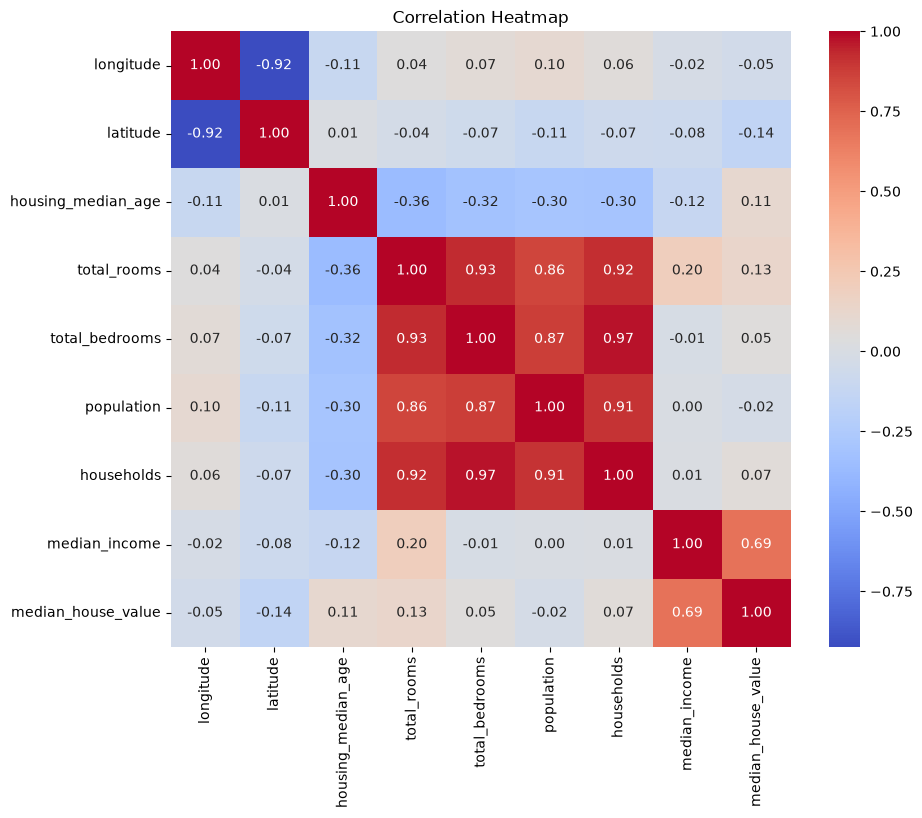

In [64]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [65]:
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

longitude: 0 outliers
latitude: 0 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1306 outliers
population: 1196 outliers
households: 1220 outliers
median_income: 681 outliers
median_house_value: 1071 outliers


In [68]:
X = df[[
    "population",
    "households",
    "total_bedrooms",
    "total_rooms",
    "median_income"
]]

y = df["median_house_value"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 5)
y shape: (20640,)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 16512
Testing rows: 4128


In [70]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ -36.84, 170.5 , 67.94, -23.79,47204.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['population','households','total_bedrooms','total_rooms','median_income']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.793e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [71]:
print("Intercept:", model1.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model1.coef_):
    print(f"{feature}: {coef:.2f}")

Intercept: 17930.998267605348

Coefficients:
population: -36.84
households: 170.50
total_bedrooms: 67.94
total_rooms: -23.79
median_income: 47204.83


In [74]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (Housing Price Prediction)")
print("R² Score:", round(score1, 4))

Model 1 (Housing Price Prediction)
R² Score: 0.5146


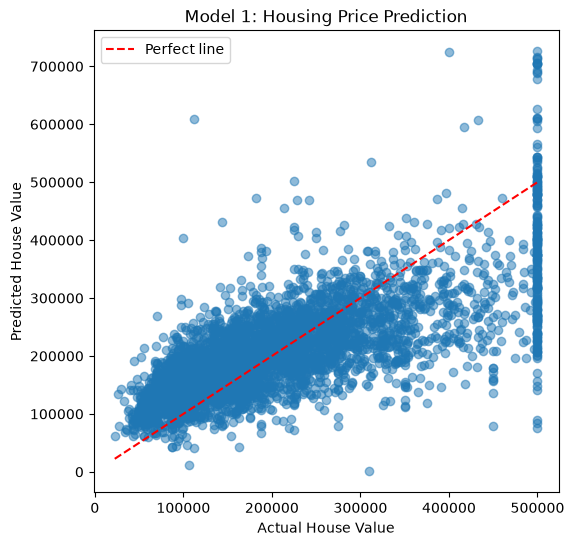

In [75]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred1, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect line'
)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Model 1: Housing Price Prediction')
plt.legend()

plt.show()

In [76]:
X2 = df[[
    'longitude',
    'latitude',
    'population',
    'households',
    'total_bedrooms',
    'total_rooms',
    'median_income'
]]

y2 = df['median_house_value']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

score2 = r2_score(y_test2, y_pred2)

print("Model 2 (Housing Price Prediction with Location)")
print("R² Score:", round(score2, 4))

Model 2 (Housing Price Prediction with Location)
R² Score: 0.6165


In [77]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1 (5 Features)',
        'Model 2 (5 Features + Location)'
    ],
    'Features Used': [
        'population, households, total_bedrooms, total_rooms, median_income',
        'population, households, total_bedrooms, total_rooms, median_income, latitude, longitude'
    ],
    'R2 Score': [
        round(score1, 4),
        round(score2, 4)
    ]
})

comparison

,Model,Features Used,R2 Score
0,Model 1 (5 Features),"population, households, total_bedrooms, total_...",0.5146
1,Model 2 (5 Features + Location),"population, households, total_bedrooms, total_...",0.6165


In [81]:
print("Model 2 expects these features:")
print(model2.feature_names_in_)

Model 2 expects these features:
['longitude' 'latitude' 'population' 'households' 'total_bedrooms'
 'total_rooms' 'median_income']


In [84]:
sample = pd.DataFrame({
    'longitude': [-118.3],
    'latitude': [34.2],
    'population': [500],
    'households': [200],
    'total_bedrooms': [100],
    'total_rooms': [500],
    'median_income': [4.5]
})

predicted_house_value = model2.predict(sample)[0]

print(f"Predicted House Value: ${predicted_house_value:,.2f}")



Predicted House Value: $233,868.33


In [88]:
X3 = df[[
    "median_income",
    "total_rooms",
    "housing_median_age",
    
]]

y3 = df["median_house_value"]


X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

score3 = r2_score(y_test3, y_pred3)

print("Model 3 (Housing Price Prediction with heatmap features)")
print("R² Score:", round(score3, 4))

Model 3 (Housing Price Prediction with heatmap features)
R² Score: 0.5045


In [90]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1 (5 Features)',
        'Model 2 (5 Features + Location)',
        'Model 3 (Heatmap Features)'
    ],
    'Features Used': [
        'population, households, total_bedrooms, total_rooms, median_income',
        'longitude, latitude, population, households, total_bedrooms, total_rooms, median_income',
        'median_income, total_rooms, housing_median_age'
    ],
    'R2 Score': [
        round(score1, 4),
        round(score2, 4),
        round(score3, 4)
    ]
})

comparison

,Model,Features Used,R2 Score
0,Model 1 (5 Features),"population, households, total_bedrooms, total_...",0.5146
1,Model 2 (5 Features + Location),"longitude, latitude, population, households, t...",0.6165
2,Model 3 (Heatmap Features),"median_income, total_rooms, housing_median_age",0.5045
